## **Statistics**

Statistics is the toolkit for using data to understand the world and make decisions. 

We split it into two categories: Descriptive (summarizing what happened) and Inferential (making predictions or conclusions about a larger population based on a sample).

In [1]:
import pandas as pd

data = {'Day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
        'Sales': [120, 150, 130, 200, 180]}
df = pd.DataFrame(data)
print(df.head())

   Day  Sales
0  Mon    120
1  Tue    150
2  Wed    130
3  Thu    200
4  Fri    180


*The above is a clean 5-row table. This represents the raw facts. Descriptive statistics will help us summarize these five days; inferential statistics would help us predict next month's sales.*

#### Types of Data

Numerical can be continuous (height: 175.5 cm) or discrete (number of siblings: 3).  
Categorical can be nominal (state of origin: Lagos, Kano, Enugu) or ordinal (customer rating: Poor, Fair, Good).

In [2]:
data = {'Age': [22, 24, 21],              # Numerical (Discrete)
        'Height_cm': [170.5, 182.0, 165.2], # Numerical (Continuous)
        'Grade': ['A', 'C', 'B'],         # Categorical (Ordinal)
        'Major': ['CS', 'Math', 'CS']}      # Categorical (Nominal)
df_students = pd.DataFrame(data)
print(df_students.dtypes)

Age            int64
Height_cm    float64
Grade         object
Major         object
dtype: object


*Pandas recognizes numbers as int64 or float64 and text as object. Knowing the data type dictates which statistical formulas and charts you are allowed to use.*

#### Descriptive Statistics

Methods used to summarize and describe data. They show what the data looks like. We need to find the "center" of the data (Mean, Median, Mode) and how "spread out" it is (Range, Variance, Standard Deviation).

In [4]:
import numpy as np

commute_times = np.array([45, 50, 42, 120, 48, 55]) 

print(f"Mean: {np.mean(commute_times)}")
print(f"Median: {np.median(commute_times)}")
print(f"Standard Deviation: {np.std(commute_times):.2f}")

Mean: 60.0
Median: 49.0
Standard Deviation: 27.14


*Mean is 60, Median is 49, Std Dev is 27.2. The mean is pulled heavily by the 120-minute outlier, making the median a better representation of a "typical" commute. The high standard deviation indicates traffic is highly unpredictable.*

#### Data Visualisation

Visualisations are graphs or charts used to represent data visually so patterns, trends, and relationships are easier to see. Numbers hide patterns; charts reveal them. Histograms show frequency, bar charts compare categories, and box plots easily highlight outliers and spread.

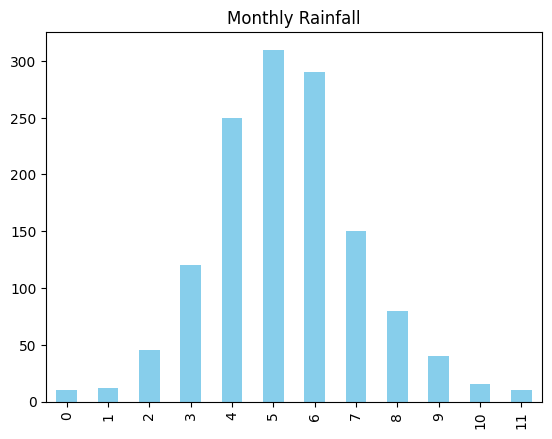

In [7]:
import matplotlib.pyplot as plt

rainfall = pd.Series([10, 12, 45, 120, 250, 310, 290, 150, 80, 40, 15, 10])
rainfall.plot(kind='bar', color='skyblue')
plt.title("Monthly Rainfall")
plt.show()

*A bar chart showing a massive spike in the middle of the year. Visually, it instantly communicates the distinct wet and dry seasons without needing to read the raw numbers.*

#### Distributions

A distribution maps out how often different values occur. The Normal Distribution (bell curve) pops up everywhere in nature. Skewed distributions lean to one side (like income, where a few people make most of the money).

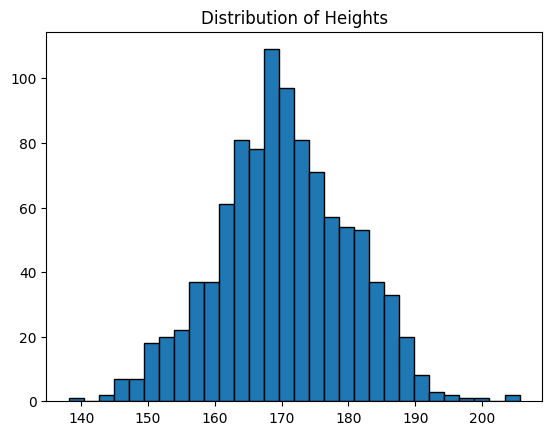

In [8]:
# Generating a normal distribution: mean=170cm, std=10cm, 1000 samples
heights = np.random.normal(170, 10, 1000)

plt.hist(heights, bins=30, edgecolor='black')
plt.title("Distribution of Heights")
plt.show()

*A symmetrical bell shape centered at 170. Most people are clustered near the average, with very few extremely tall or extremely short outliers.*

#### Probability (Basics)

Probability is the mathematical language of uncertainty, scaling from 0 (impossible) to 1 (guaranteed). Events can be independent (flipping a coin twice) or dependent (drawing cards without replacement).

In [9]:
tosses = np.random.choice(['Heads', 'Tails'], size=10000)
results = pd.Series(tosses).value_counts(normalize=True)
print(results)

Heads    0.5048
Tails    0.4952
Name: proportion, dtype: float64


*Output will be roughly Heads: 0.50, Tails: 0.50. Even though each toss is random, in the long run, the results converge to their true probability.*

#### Sampling

We rarely have data for the whole population, so we take a sample. If the sample isn't random, we get bias (e.g., asking only gym members how much they exercise to estimate the city's fitness).

In [10]:
population = pd.Series(np.random.normal(70, 15, 10000))
sample = population.sample(n=100, random_state=42)

print(f"Population Mean: {population.mean():.2f}")
print(f"Sample Mean: {sample.mean():.2f}")

Population Mean: 69.81
Sample Mean: 70.32


*The sample mean is very close to the population mean. This shows that a well-chosen, randomized sample accurately reflects the much larger population without needing to measure everything.*

#### Inferential Statistics

Methods used to make conclusions or predictions about a larger population based on a sample of data.  
A Confidence Interval gives us a range where we think the true population number lives. Hypothesis testing asks: "Is the effect we are seeing real, or just random luck?"

In [11]:
# Intuition test: difference of means
fertilizer_a = np.array([30, 32, 31, 29, 33, 31, 30, 32, 31, 30])
fertilizer_b = np.array([35, 36, 34, 37, 35, 36, 38, 35, 36, 37])

diff = np.mean(fertilizer_b) - np.mean(fertilizer_a)
print(f"Difference in yield: {diff:.2f}")

Difference in yield: 5.00


*There is a clear difference of about 5 units. Inferential math (like a t-test) would formally tell us if a 5-unit difference is large enough to be statistically significant based on the variance, but intuitively, Fertilizer B is consistently outperforming A.*

#### Correlation and Causation

Correlation measures if two variables move together. Causation means one actually makes the other happen. A classic trap in AI and data analysis is assuming that because two things correlate, they are causally linked.

In [12]:
data = {'Temp_C': [25, 30, 35, 40, 38],
        'Ice_Cream_Sales': [100, 150, 200, 300, 280],
        'Generator_Sales': [10, 15, 25, 40, 35]}
df_spurious = pd.DataFrame(data)
print(df_spurious.corr())

                   Temp_C  Ice_Cream_Sales  Generator_Sales
Temp_C           1.000000         0.981628         0.979397
Ice_Cream_Sales  0.981628         1.000000         0.995221
Generator_Sales  0.979397         0.995221         1.000000


*The correlation matrix shows a correlation near 0.99 between Ice Cream and Generators. Interpretation: Buying ice cream doesn't cause people to buy generators. A hidden third variable (high temperature) is causing both.*

#### Mini Practice Section

Explanation: A tiny capstone to test the concepts. Spot the bad data, calculate the right metrics, and make a decision.

Dataset: Salary data for 6 junior AI engineers (in millions of Naira), but one value is corrupted.

In [13]:
# The dataset contains a massive outlier
salaries = pd.Series([3.2, 3.5, 3.1, 4.0, 3.8, 95.0]) 

print("Mean:", salaries.mean())
print("Median:", salaries.median())

# Simple fix
clean_salaries = salaries[salaries < 10.0]
print("Clean Mean:", clean_salaries.mean())

Mean: 18.766666666666666
Median: 3.65
Clean Mean: 3.5200000000000005


*The initial mean is distorted (~18.7M), but the median is stable (~3.6M). We identify the 95.0 as a likely data entry error or an extreme outlier. Removing the bias allows us to calculate the true underlying distribution (Clean Mean: 3.52M). Always look at the data before blinding trusting the average!*